In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import matplotlib.pyplot as plt

In [2]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

In [3]:
plants = []

genera = {
    'List_of_Pinus_species': ('Pinus', 'Pinaceae', 'Tree'),
    'List_of_Rosa_species': ('Rosa', 'Rosaceae', 'Shrub'),
    'List_of_Iris_species': ('Iris', 'Iridaceae', 'Perennial'),
    'List_of_Eucalyptus_species': ('Eucalyptus', 'Myrtaceae', 'Tree')
}

In [4]:
for page_name, (genus, family, plant_type) in genera.items():
  try:
      print(f"Scraping {genus}:", end=" ")

      url = f"https://en.wikipedia.org/wiki/{page_name}"
      response = requests.get(url, headers=headers)

      if response.status_code == 200:
          soup = BeautifulSoup(response.content, 'html.parser')

          list_items = soup.find_all('li')
          gencon = 0
          for item in list_items:
              italic = item.find('i')
              if italic:
                  scientific_name = italic.get_text(strip=True)
                  if scientific_name.startswith(genus):
                      text = item.get_text()
                      parts = text.split('–')

                      common_name = 'N/A'
                      region = 'N/A'

                      if len(parts) >= 2:
                          common_name = parts[1].strip().split('#')[0].strip()
                          region = parts[-1].strip()

                      plants.append({
                          'Scientific_Name': scientific_name,
                          'Common_Names': common_name,
                          'Genus': genus,
                          'Family': family,
                          'Plant_Type': plant_type,
                          'Native_Region': region
                      })

                      gencon += 1

          print(f"{gencon} species")
          time.sleep(1)

  except Exception as e:
      print(f"Error: {e}")
      continue


Scraping Pinus: 25 species
Scraping Rosa: 332 species
Scraping Iris: 269 species
Scraping Eucalyptus: 997 species


In [5]:
df = pd.DataFrame(plants)
df.head()

,Scientific_Name,Common_Names,Genus,Family,Plant_Type,Native_Region
0,Pinus,N/A,Pinus,Pinaceae,Tree,N/A
1,Pinus,N/A,Pinus,Pinaceae,Tree,N/A
2,Pinus,N/A,Pinus,Pinaceae,Tree,N/A
3,Pinus latahensis,"Early Eocene, Klondike Mountain Formation, All...",Pinus,Pinaceae,Tree,Okanagan Highlands Floras
4,Pinus macrophylla,"Early Eocene, Klondike Mountain Formation, All...",Pinus,Pinaceae,Tree,Okanagan Highlands Floras


In [6]:
df = df.drop_duplicates(subset=['Scientific_Name'])
df.head()

,Scientific_Name,Common_Names,Genus,Family,Plant_Type,Native_Region
0,Pinus,N/A,Pinus,Pinaceae,Tree,N/A
3,Pinus latahensis,"Early Eocene, Klondike Mountain Formation, All...",Pinus,Pinaceae,Tree,Okanagan Highlands Floras
4,Pinus macrophylla,"Early Eocene, Klondike Mountain Formation, All...",Pinus,Pinaceae,Tree,Okanagan Highlands Floras
5,Pinus peregrinus,"Middle Eocene, Golden Valley Formation, North ...",Pinus,Pinaceae,Tree,"Middle Eocene, Golden Valley Formation, North ..."
6,Pinus tetrafolia,"Early Eocene, Klondike Mountain Formation",Pinus,Pinaceae,Tree,Okanagan Highlands Floras


In [7]:
df['Plant_ID'] = range(1, len(df) + 1)
df.head()

,Scientific_Name,Common_Names,Genus,Family,Plant_Type,Native_Region,Plant_ID
0,Pinus,N/A,Pinus,Pinaceae,Tree,N/A,1
3,Pinus latahensis,"Early Eocene, Klondike Mountain Formation, All...",Pinus,Pinaceae,Tree,Okanagan Highlands Floras,2
4,Pinus macrophylla,"Early Eocene, Klondike Mountain Formation, All...",Pinus,Pinaceae,Tree,Okanagan Highlands Floras,3
5,Pinus peregrinus,"Middle Eocene, Golden Valley Formation, North ...",Pinus,Pinaceae,Tree,"Middle Eocene, Golden Valley Formation, North ...",4
6,Pinus tetrafolia,"Early Eocene, Klondike Mountain Formation",Pinus,Pinaceae,Tree,Okanagan Highlands Floras,5


In [8]:
columns = ['Plant_ID', 'Scientific_Name', 'Common_Names', 'Genus', 'Family',
                   'Plant_Type', 'Native_Region']
df = df[columns]
df.head()

,Plant_ID,Scientific_Name,Common_Names,Genus,Family,Plant_Type,Native_Region
0,1,Pinus,N/A,Pinus,Pinaceae,Tree,N/A
3,2,Pinus latahensis,"Early Eocene, Klondike Mountain Formation, All...",Pinus,Pinaceae,Tree,Okanagan Highlands Floras
4,3,Pinus macrophylla,"Early Eocene, Klondike Mountain Formation, All...",Pinus,Pinaceae,Tree,Okanagan Highlands Floras
5,4,Pinus peregrinus,"Middle Eocene, Golden Valley Formation, North ...",Pinus,Pinaceae,Tree,"Middle Eocene, Golden Valley Formation, North ..."
6,5,Pinus tetrafolia,"Early Eocene, Klondike Mountain Formation",Pinus,Pinaceae,Tree,Okanagan Highlands Floras


### Summary

In [9]:
print("Summary of the data:")
print("Total scraped data:",len(df))
print("Total columns in data:",len(df.columns))

Summary of the data:
Total scraped data: 1267
Total columns in data: 7


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1267 entries, 0 to 1622
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Plant_ID         1267 non-null   int64 
 1   Scientific_Name  1267 non-null   object
 2   Common_Names     1267 non-null   object
 3   Genus            1267 non-null   object
 4   Family           1267 non-null   object
 5   Plant_Type       1267 non-null   object
 6   Native_Region    1267 non-null   object
dtypes: int64(1), object(6)
memory usage: 79.2+ KB


In [11]:
print("Total records in particular Genus:")
print(df['Genus'].value_counts())

Total records in particular Genus:
Genus
Eucalyptus    741
Iris          259
Rosa          250
Pinus          17
Name: count, dtype: int64


In [12]:
df.to_csv('BotanicalPlants.csv', index=False)

## Analysis

#### Top Genus Distributions

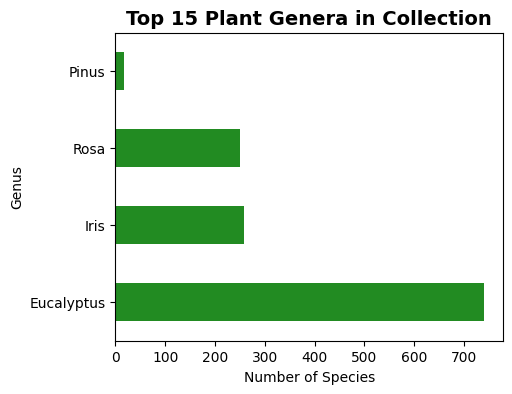

In [13]:
plt.figure(figsize=(5, 4))
df['Genus'].value_counts().plot(kind='barh', color='forestgreen')
plt.title('Top 15 Plant Genera in Collection', fontsize=14, fontweight='bold')
plt.xlabel('Number of Species')
plt.ylabel('Genus')
plt.show()

#### Plant Type Distribution

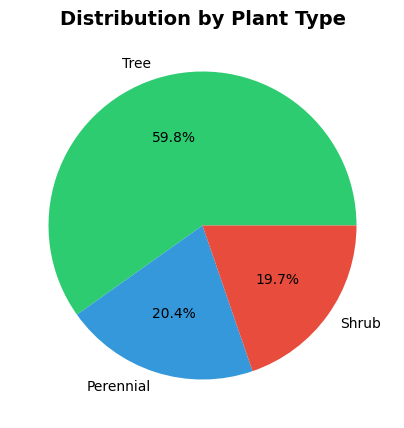

In [14]:
plt.figure(figsize=(5,5))
df['Plant_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                      colors=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Distribution by Plant Type', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()